# 서울시 가구 인원별 세대수 증감 분석
- 원본: `202112_202512_주민등록인구기타현황(세대원수별 세대수)_월간.csv`
- 인코딩: EUC-KR
- 서울특별시만 추출, 5인 이상 세대는 하나로 그룹화

In [47]:
import pandas as pd

# CSV 로드 (EUC-KR 인코딩)
CSV_PATH = "../202112_202512_주민등록인구기타현황(세대원수별 세대수)_월간.csv"
df_raw = pd.read_csv(CSV_PATH, encoding="euc-kr")
print(f"shape: {df_raw.shape}")
print(f"columns 예시: {list(df_raw.columns[:6])}")
df_raw.head(3)

shape: (20, 540)
columns 예시: ['행정구역', '2021년12월_전체세대', '2021년12월_1인세대', '2021년12월_2인세대', '2021년12월_3인세대', '2021년12월_4인세대']


,행정구역,2021년12월_전체세대,2021년12월_1인세대,2021년12월_2인세대,2021년12월_3인세대,2021년12월_4인세대,2021년12월_5인세대,2021년12월_6인세대,2021년12월_7인세대,2021년12월_8인세대,...,2025년12월_1인세대,2025년12월_2인세대,2025년12월_3인세대,2025년12월_4인세대,2025년12월_5인세대,2025년12월_6인세대,2025년12월_7인세대,2025년12월_8인세대,2025년12월_9인세대,2025년12월_10인이상세대
0,전국 (1000000000),"23,472,895","9,461,695","5,613,943","3,998,644","3,369,721","817,794","160,409","36,020","9,249",...,"10,272,573","6,150,418","4,075,321","2,959,639","671,957","128,571","29,212","7,643","2,401","2,352"
1,서울특별시 (1100000000),"4,426,007","1,906,690","978,393","750,762","616,312","135,649","28,628","6,705","1,848",...,"2,029,785","1,031,855","750,246","541,782","114,282","24,440","6,015","1,707",538,381
2,부산광역시 (2600000000),"1,544,663","615,618","394,176","270,214","206,023","46,762","9,122","1,958",478,...,"670,077","420,461","263,724","173,733","36,963","6,845","1,554",369,135,135


## 서울 추출 + 컬럼 파싱 → long format 변환

In [48]:
# 서울 행만 추출
df_seoul = df_raw[df_raw["행정구역"].str.contains("서울")].copy()
print(f"서울 행: {len(df_seoul)}")

# wide → long: 행정구역 제외한 나머지 컬럼을 melt
df_long = df_seoul.melt(id_vars=["행정구역"], var_name="col", value_name="세대수")

# 컬럼명 파싱: "2021년12월_1인세대" → 연월, 세대유형
df_long["연월"] = df_long["col"].str.extract(r"(\d{4}년\d{2}월)")
df_long["유형"] = df_long["col"].str.extract(r"_(.+)$")
df_long = df_long.drop(columns=["col", "행정구역"])

# 전체세대 행은 별도 보관 후 제외 (인원별 분석에 불필요)
df_total = df_long[df_long["유형"] == "전체세대"].copy()
df_long = df_long[df_long["유형"] != "전체세대"].copy()

# 세대수: 콤마 제거 → 숫자 변환
df_long["세대수"] = pd.to_numeric(df_long["세대수"].astype(str).str.replace(",", ""), errors="coerce")

print(f"long format shape: {df_long.shape}")
df_long.head()

서울 행: 1
long format shape: (490, 3)


,세대수,연월,유형
1,1906690,2021년12월,1인세대
2,978393,2021년12월,2인세대
3,750762,2021년12월,3인세대
4,616312,2021년12월,4인세대
5,135649,2021년12월,5인세대


## 5인 이상 그룹화

In [49]:
# 4인 이상 통합 (4인 + 5인이상 → 4인이상세대)
def group_type(t):
    if t in ("1인세대", "2인세대", "3인세대"):
        return t
    return "4인이상세대"

df_long["유형"] = df_long["유형"].map(group_type)

# 같은 연월 + 유형끼리 합산
df = df_long.groupby(["연월", "유형"], as_index=False)["세대수"].sum()

# 연월 정렬용 날짜 컬럼
df["date"] = pd.to_datetime(df["연월"].str.replace("년", "-").str.replace("월", ""), format="%Y-%m")
df = df.sort_values("date")

print(f"유형 목록: {sorted(df['유형'].unique())}")
print(f"연월 범위: {df['date'].min()} ~ {df['date'].max()}")
df.head(10)

유형 목록: ['1인세대', '2인세대', '3인세대', '4인이상세대']
연월 범위: 2021-12-01 00:00:00 ~ 2025-12-01 00:00:00


,연월,유형,세대수,date
0,2021년12월,1인세대,1906690,2021-12-01
1,2021년12월,2인세대,978393,2021-12-01
2,2021년12월,3인세대,750762,2021-12-01
3,2021년12월,4인이상세대,790162,2021-12-01
4,2022년01월,1인세대,1912938,2022-01-01
5,2022년01월,2인세대,979236,2022-01-01
6,2022년01월,3인세대,750842,2022-01-01
7,2022년01월,4인이상세대,787525,2022-01-01
8,2022년02월,1인세대,1926211,2022-02-01
9,2022년02월,2인세대,981260,2022-02-01


## 결과 확인 (pivot)

In [50]:
# 전체세대도 숫자 변환
df_total["세대수"] = pd.to_numeric(df_total["세대수"].astype(str).str.replace(",", ""), errors="coerce")
df_total["date"] = pd.to_datetime(df_total["연월"].str.replace("년", "-").str.replace("월", ""), format="%Y-%m")

# pivot: 연월 × 유형별 세대수
df_pivot = df.pivot(index="date", columns="유형", values="세대수")
df_pivot = df_pivot[["1인세대", "2인세대", "3인세대", "4인이상세대"]]

# 전체세대 컬럼 추가
df_pivot["전체세대"] = df_total.set_index("date")["세대수"]
df_pivot = df_pivot[["전체세대", "1인세대", "2인세대", "3인세대", "4인이상세대"]]
df_pivot

유형,전체세대,1인세대,2인세대,3인세대,4인이상세대
date,,,,,
2021-12-01,4426007,1906690,978393,750762,790162
2022-01-01,4430541,1912938,979236,750842,787525
2022-02-01,4442586,1926211,981260,751191,783924
2022-03-01,4451444,1936401,983457,751215,780371
2022-04-01,4455106,1942348,984417,750874,777467
2022-05-01,4460604,1949213,986480,750614,774297
2022-06-01,4464840,1954624,987846,750212,772158
2022-07-01,4469392,1960852,988300,750104,770136
2022-08-01,4472975,1966825,988641,750136,767373


In [51]:
import os

# date → 연, 월 분리 (일 제거)
df_out = df_pivot.copy()
df_out.index = pd.to_datetime(df_out.index)
df_out.insert(0, "연", df_out.index.year)
df_out.insert(1, "월", df_out.index.month)
df_out = df_out.reset_index(drop=True)

# CSV 저장
output_path = "../data/seoul_household.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {output_path}")
df_out.head()

저장 완료: ../data/seoul_household.csv


유형,연,월,전체세대,1인세대,2인세대,3인세대,4인이상세대
0,2021,12,4426007,1906690,978393,750762,790162
1,2022,1,4430541,1912938,979236,750842,787525
2,2022,2,4442586,1926211,981260,751191,783924
3,2022,3,4451444,1936401,983457,751215,780371
4,2022,4,4455106,1942348,984417,750874,777467


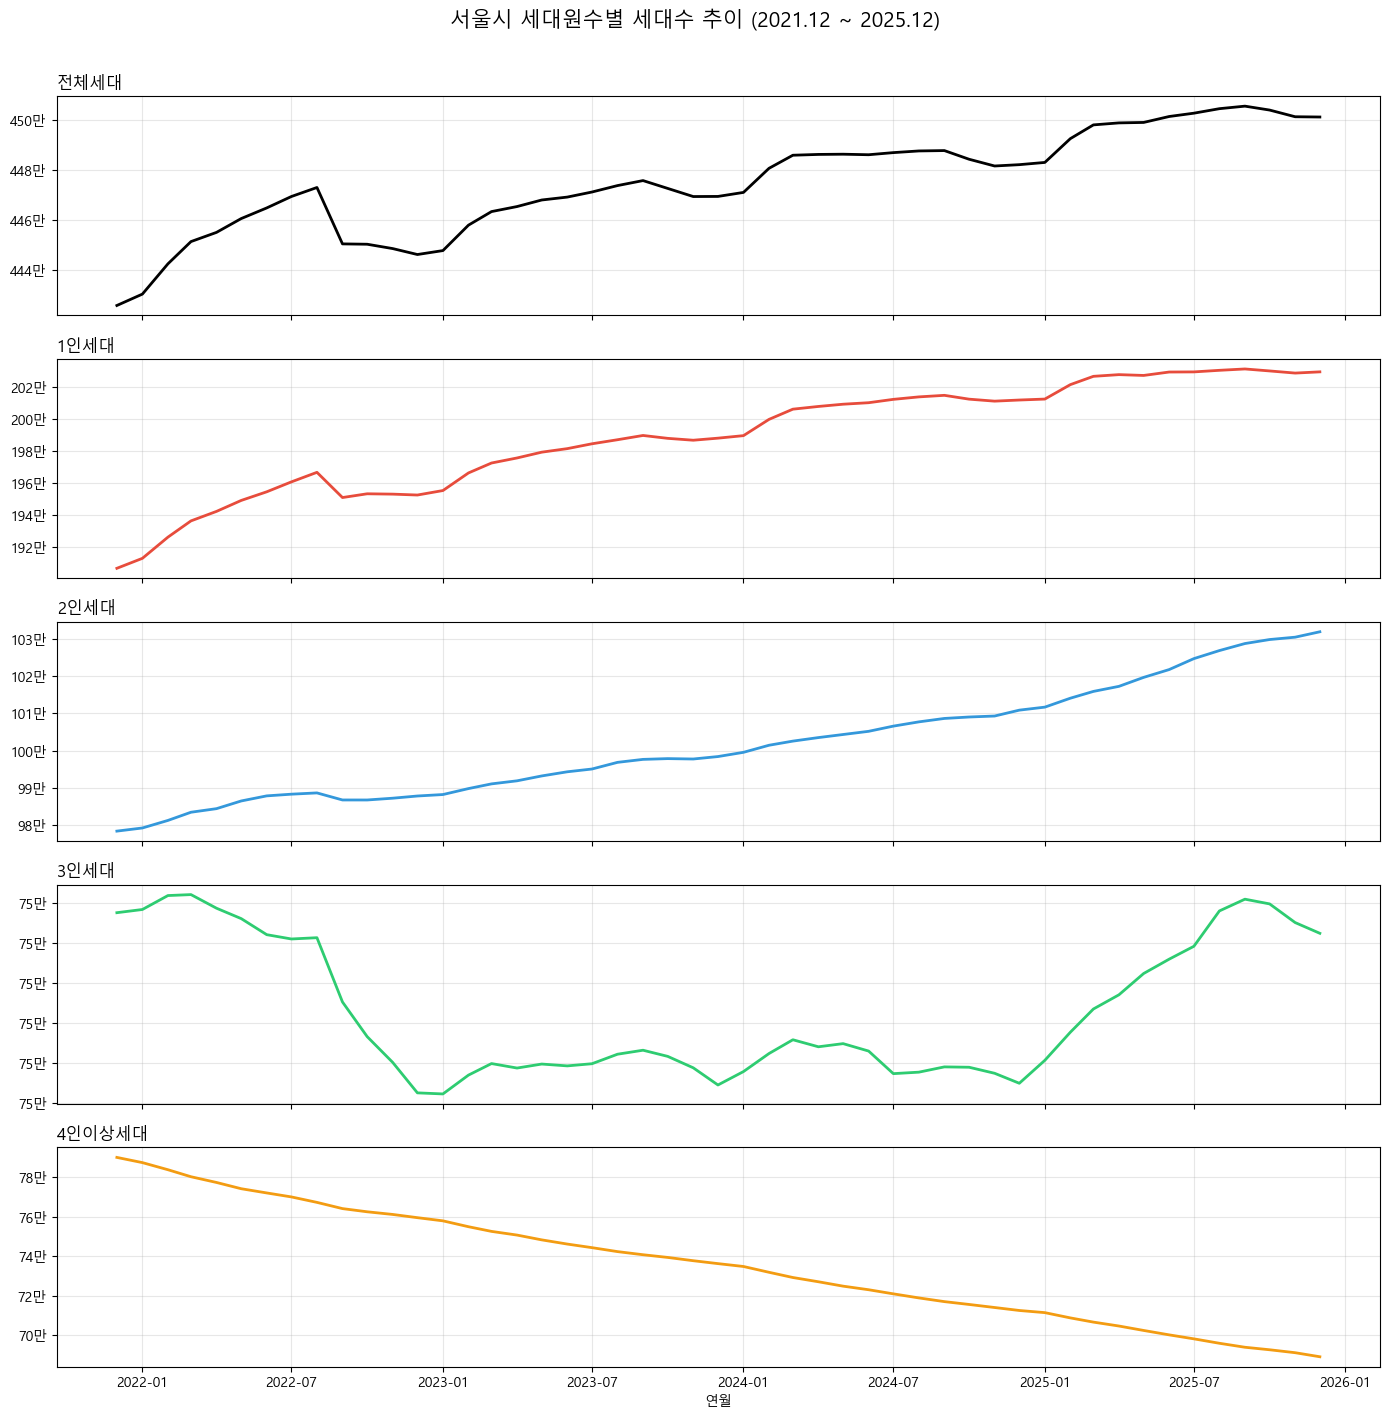

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

cols = ["전체세대", "1인세대", "2인세대", "3인세대", "4인이상세대"]
colors = ["black", "#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

fig, axes = plt.subplots(len(cols), 1, figsize=(14, 14), sharex=True)

for ax, col, c in zip(axes, cols, colors):
    ax.plot(df_pivot.index, df_pivot[col], color=c, linewidth=2)
    ax.set_title(col, fontsize=12, loc="left")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/10000:.0f}만"))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("연월")
fig.suptitle("서울시 세대원수별 세대수 추이 (2021.12 ~ 2025.12)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()